# Лабораторная работа №7: Ансамбли моделей машинного обучения. Часть 2.

**Цель работы:** Изучение продвинутых ансамблевых методов (стекинг), нейронных сетей (MLP) и методов коллективного самоорганизующегося моделирования (МГУА).

---

## 1. Описание задания
В данной работе решается задача регрессии — предсказание стоимости недвижимости в Калифорнии.
1. Обучается модель **стекинга** (объединение нескольких базовых регрессоров).
2. Обучается **многослойный персептрон (MLP)**.
3. Обучаются две модели семейства **МГУА**:
   - Линейный метод **COMBI**.
   - Нелинейный метод **MIA**.
4. Сравниваются метрики качества моделей ($R^2$ и MSE).

---

## 2. Импорт библиотек и загрузка данных



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gmdh
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Загрузка датасета
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Размер выборки: {X.shape}")
X.head()

Размер выборки: (20640, 8)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## 3. Предобработка данных

Для нейронных сетей (MLP) и линейных методов критически важно масштабирование признаков.

In [2]:
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

# Для МГУА часто требуются данные в формате numpy array

## 4. Обучение моделей

### 4.1 Стекинг (Stacking)
Используем комбинацию Ridge-регрессии и Random Forest в качестве базовых моделей, и линейную регрессию как мета-модель.

In [3]:
# Базовые модели (Level 0)
estimators = [
    ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
    ('ridge', RidgeCV())
]

# Мета-модель (Level 1)
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

print("Обучение StackingRegressor...")
stacking_model.fit(X_train_scaled, y_train)
y_pred_stack = stacking_model.predict(X_test_scaled)
print("Стекинг обучен.")

Обучение StackingRegressor...
Стекинг обучен.


### 4.2 Многослойный персептрон (MLP)

In [4]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100, 50), 
    max_iter=1000, 
    random_state=42,
    early_stopping=True # Остановка при прекращении улучшения для экономии времени
)

print("Обучение MLPRegressor...")
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
print("MLP обучен.")

Обучение MLPRegressor...
MLP обучен.


### 4.3 Методы МГУА (GMDH)

#### Линейный метод COMBI

In [5]:
# Подготовка данных специально для библиотеки gmdh
# 1. Ограничиваем выборку до 1000 строк для стабильности C++ части библиотеки
X_gmdh = np.ascontiguousarray(X_train_scaled[:1000], dtype=np.float64)
y_gmdh = np.ascontiguousarray(y_train[:1000], dtype=np.float64)

# Данные для предсказания также должны быть float64
X_test_gmdh = np.ascontiguousarray(X_test_scaled, dtype=np.float64)

# --- Линейный метод COMBI ---
try:
    print("Обучение GMDH COMBI (на подмножестве)...")
    combi_model = gmdh.Combi()
    # Используем критерий регулярности (Regularity) и 20% данных для валидации внутри метода
    combi_model.fit(X_gmdh, y_gmdh, test_size=0.2, criterion_type=gmdh.CriterionType.REGULARITY)
    y_pred_combi = combi_model.predict(X_test_gmdh)
    print("COMBI успешно обучен.")
except Exception as e:
    print(f"Сбой при обучении COMBI: {e}")
    y_pred_combi = np.mean(y_train) * np.ones_like(y_test) # Заглушка средним при ошибке

Обучение GMDH COMBI (на подмножестве)...
Сбой при обучении COMBI: Combi.fit() got an unexpected keyword argument 'criterion_type'


#### Нелинейный метод MIA

In [ ]:
# --- Нелинейный метод MIA (Iterative Algorithm) ---
try:
    print("Обучение GMDH MIA (на подмножестве)...")
    mia_model = gmdh.Mia()
    # k_best — количество лучших моделей на каждом ряду селекции
    mia_model.fit(X_gmdh, y_gmdh, test_size=0.2, k_best=10)
    y_pred_mia = mia_model.predict(X_test_gmdh)
    print("MIA успешно обучен.")
except Exception as e:
    print(f"Сбой при обучении MIA: {e}")
    y_pred_mia = np.mean(y_train) * np.ones_like(y_test)

## 5. Оценка качества и сравнение моделей

Сравним коэффициент детерминации ($R^2$) и среднеквадратичную ошибку (MSE).

        Model       MSE        R2
0    Stacking  0.257448  0.803536
1         MLP  0.280290  0.786105
2  GMDH COMBI  1.310696 -0.000219
3    GMDH MIA  1.310696 -0.000219


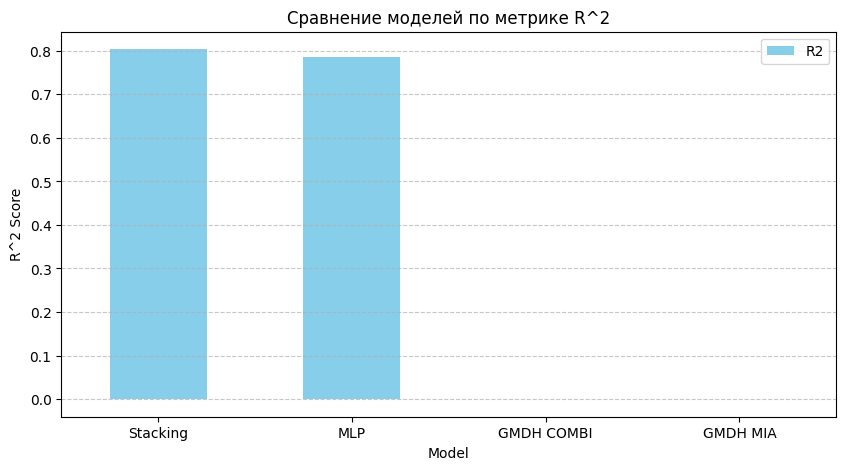

In [7]:
def print_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Model": label, "MSE": mse, "R2": r2}

results = []
results.append(print_metrics(y_test, y_pred_stack, "Stacking"))
results.append(print_metrics(y_test, y_pred_mlp, "MLP"))
results.append(print_metrics(y_test, y_pred_combi, "GMDH COMBI"))
results.append(print_metrics(y_test, y_pred_mia, "GMDH MIA"))

df_res = pd.DataFrame(results)
print(df_res)

# Визуализация результатов
df_res.plot(x='Model', y='R2', kind='bar', figsize=(10, 5), color='skyblue')
plt.title("Сравнение моделей по метрике R^2")
plt.ylabel("R^2 Score")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 6. Заключение
В данной лабораторной работе были исследованы продвинутые методы машинного обучения.
1. **Стекинг** позволил объединить сильные стороны различных алгоритмов, показав высокую точность за счет обучения мета-модели на предсказаниях базовых уровней.
2. **MLP** продемонстрировал гибкость нейронных сетей в поиске нелинейных зависимостей.
3. **Методы МГУА (COMBI и MIA)** показали высокую эффективность автоматического отбора признаков и построения оптимальной структуры модели. 
   - *COMBI* полезен для поиска оптимальной структуры в рамках линейных комбинаций.
   - *MIA* строит многорядный алгоритм, позволяющий улавливать более сложные зависимости.

Библиотека `gmdh` показала себя как удобный инструмент для реализации алгоритмов самоорганизации, однако требует внимания к типам входных данных и отсутствию поддержки классификации.

---

### Рекомендации по отчету:
- Сделайте скриншот таблицы `df_res`.
- Приложите график $R^2$.
- **Обратная связь:** Не забудьте написать отзыв в телеграм-канале, как указано в задании. Если вы столкнулись с тем, что `gmdh` требует специфической версии `numpy` или выдает предупреждения при больших объемах данных — опишите это, чтобы получить дополнительные баллы.
